### Classification of regression errors using a relative error tolerance

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


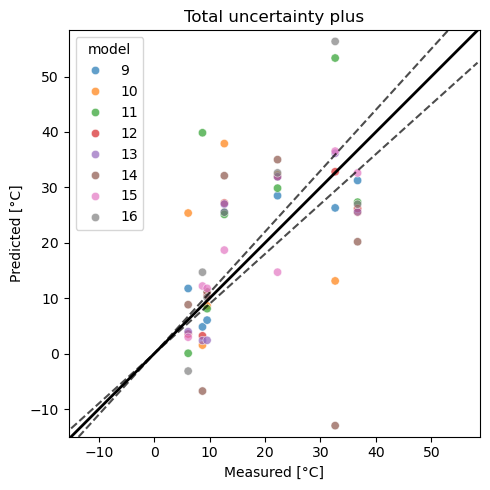

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TOLERANCE=0.1

folder = "interp_reg_spatial"

metric = "total_plus"

models = [
    "9", "10", "11", "12", "13", "14", "15", "16"
]

dfs = []

for model in models:
    df = pd.read_csv(f"../../{folder}/ablation_results/{metric}_ablation_{model}.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

fig, ax = plt.subplots(figsize=(5, 5))

# Scatter points
sns.scatterplot(
    data=df_all,
    x="measured",
    y="predicted",
    hue="model",
    alpha=0.7,
    ax=ax
)

# 95% error bars
yerr = np.vstack([
    df_all["predicted"] - df_all["lower_95"],
    df_all["upper_95"] - df_all["predicted"]
])

# ax.errorbar(
#     df_all["measured"],
#     df_all["predicted"],
#     yerr=yerr,
#     fmt="none",
#     ecolor="gray",
#     alpha=0.5,
#     capsize=2,
#     linewidth=1
# )

# lims = [
#     min(df_all["measured"].min(), df_all["predicted"].min(), df_all["lower_95"].min()),
#     max(df_all["measured"].max(), df_all["predicted"].max(), df_all["upper_95"].max())
# ]

lims = [
    min(df_all["measured"].min(), df_all["predicted"].min()) - 2,
    max(df_all["measured"].max(), df_all["predicted"].max()) + 2
]

x = np.linspace(lims[0], lims[1], 100)

# Ideal line
ax.plot(x, x, "k-", linewidth=2, label="Ideal")

# ±10% tolerance
ax.plot(x, (1.0 + TOLERANCE) * x, "k--", alpha=0.7, label="±10%")
ax.plot(x, (1.0 - TOLERANCE) * x, "k--", alpha=0.7)

ax.axis("equal")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Measured [°C]")
ax.set_ylabel("Predicted [°C]")

ax.set_title("Total uncertainty plus")


plt.tight_layout()
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


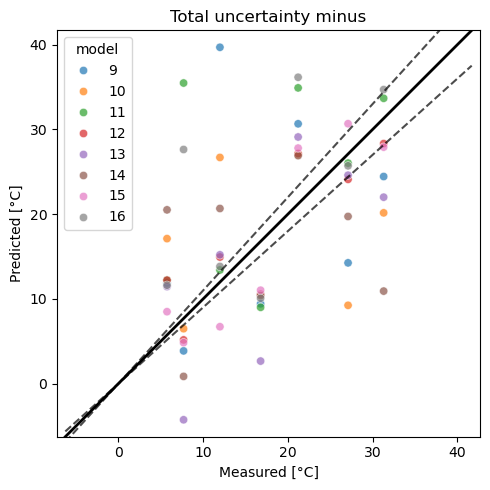

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TOLERANCE=0.1

metric = "total_minus"

dfs = []

for model in models:
    df = pd.read_csv(f"../../{folder}/ablation_results/{metric}_ablation_{model}.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

fig, ax = plt.subplots(figsize=(5, 5))

# Scatter points
sns.scatterplot(
    data=df_all,
    x="measured",
    y="predicted",
    hue="model",
    alpha=0.7,
    ax=ax
)

# 95% error bars
yerr = np.vstack([
    df_all["predicted"] - df_all["lower_95"],
    df_all["upper_95"] - df_all["predicted"]
])

# ax.errorbar(
#     df_all["measured"],
#     df_all["predicted"],
#     yerr=yerr,
#     fmt="none",
#     ecolor="gray",
#     alpha=0.5,
#     capsize=2,
#     linewidth=1
# )

# lims = [
#     min(df_all["measured"].min(), df_all["predicted"].min(), df_all["lower_95"].min()),
#     max(df_all["measured"].max(), df_all["predicted"].max(), df_all["upper_95"].max())
# ]

lims = [
    min(df_all["measured"].min(), df_all["predicted"].min()) - 2,
    max(df_all["measured"].max(), df_all["predicted"].max()) + 2
]

x = np.linspace(lims[0], lims[1], 100)

# Ideal line
ax.plot(x, x, "k-", linewidth=2, label="Ideal")

# ±10% tolerance
ax.plot(x, (1.0 + TOLERANCE) * x, "k--", alpha=0.7, label="±10%")
ax.plot(x, (1.0 - TOLERANCE) * x, "k--", alpha=0.7)

ax.axis("equal")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Measured [°C]")
ax.set_ylabel("Predicted [°C]")

ax.set_title("Total uncertainty minus")

plt.tight_layout()
plt.show()

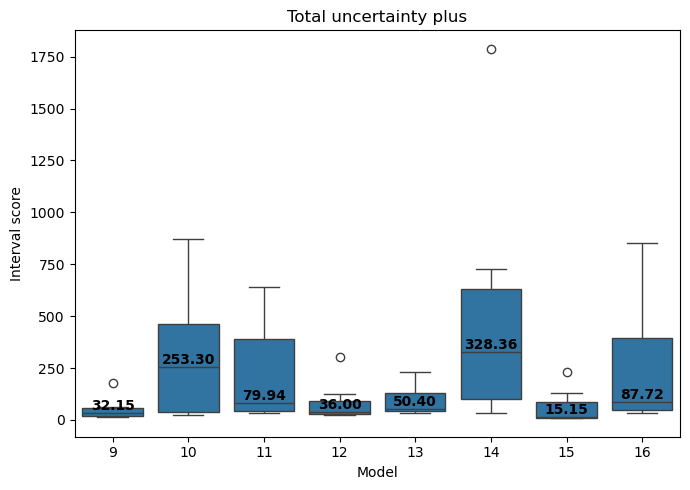

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "total_plus"

dfs = []

for model in models:
    df = pd.read_csv(f"../../{folder}/ablation_results/{metric}_ablation_{model}.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# enforce categorical order
df_all["model"] = pd.Categorical(df_all["model"], categories=models, ordered=True)

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df_all,
    x="model",
    y="interval_score",
    order=models
)

# compute medians in SAME order
medians = df_all.groupby("model", observed=False)["interval_score"].median().reindex(models)

# add labels aligned to x positions
for i, model in enumerate(models):
    y = medians.loc[model]
    ax.text(
        i, y,
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Interval score")
plt.xlabel("Model")

ax.set_title("Total uncertainty plus")

plt.tight_layout()
plt.show()

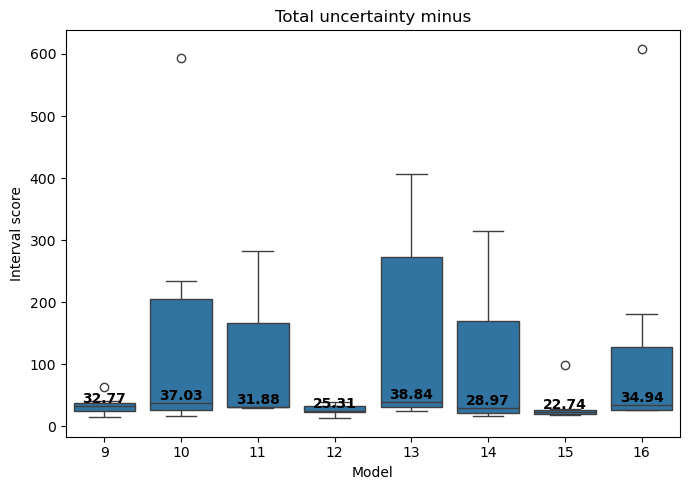

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "total_minus"

dfs = []

for model in models:
    df = pd.read_csv(f"../../{folder}/ablation_results/{metric}_ablation_{model}.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# enforce categorical order
df_all["model"] = pd.Categorical(df_all["model"], categories=models, ordered=True)

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df_all,
    x="model",
    y="interval_score",
    order=models
)

# compute medians in SAME order
medians = df_all.groupby("model", observed=False)["interval_score"].median().reindex(models)

# add labels aligned to x positions
for i, model in enumerate(models):
    y = medians.loc[model]
    ax.text(
        i, y,
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Interval score")
plt.xlabel("Model")

ax.set_title("Total uncertainty minus")

plt.tight_layout()
plt.show()

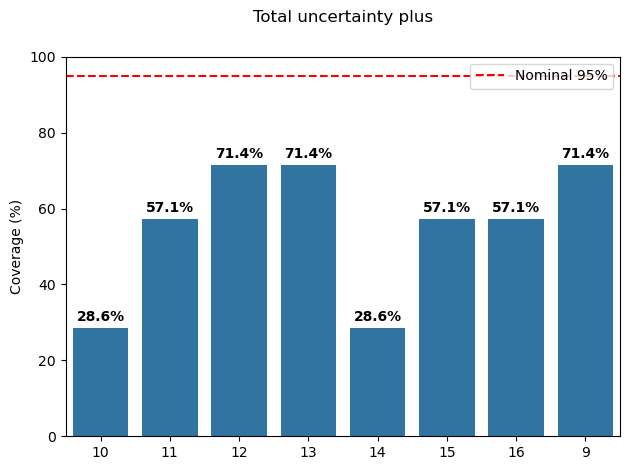

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "total_plus"

dfs = []

for model in models:
    df = pd.read_csv(f"../../{folder}/ablation_results/{metric}_ablation_{model}.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

coverage = (
    df_all.groupby("model")["within_pi"]
    .mean()              # True=1, False=0
    .mul(100)            # convert to %
    .reset_index(name="coverage")
)

ax = sns.barplot(
    data=coverage,
    x="model",
    y="coverage"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")


ax.set_title("Total uncertainty plus", pad=25)

plt.ylabel("Coverage (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.axhline(95, color="red", linestyle="--", label="Nominal 95%")
plt.legend()
plt.tight_layout()
plt.show()

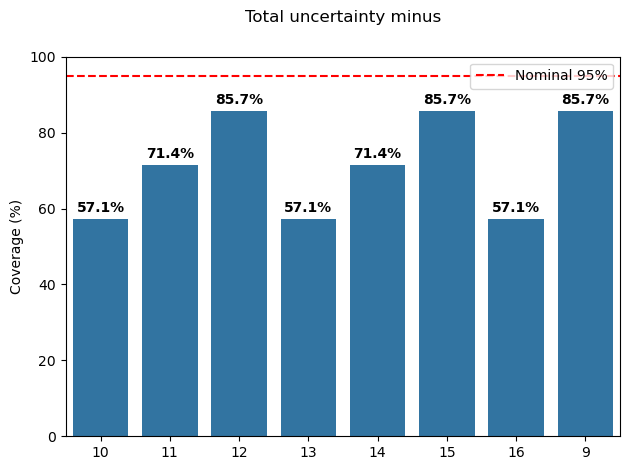

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metric = "total_minus"

dfs = []

for model in models:
    df = pd.read_csv(f"../../{folder}/ablation_results/{metric}_ablation_{model}.csv")
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

coverage = (
    df_all.groupby("model")["within_pi"]
    .mean()              # True=1, False=0
    .mul(100)            # convert to %
    .reset_index(name="coverage")
)

ax = sns.barplot(
    data=coverage,
    x="model",
    y="coverage"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")


ax.set_title("Total uncertainty minus", pad=25)

plt.ylabel("Coverage (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.axhline(95, color="red", linestyle="--", label="Nominal 95%")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
best_model = "4"

model_df_all = pd.read_csv(f"../../{folder}/ablation_summary_{best_model}.csv")

model_df = model_df_all[model_df_all["d_type"] == "total_plus"]

print(f"Best model: {best_model}")

print("Total uncertainty plus")
print(
    model_df_all.loc[
        model_df_all["d_type"] == "total_plus",
        ["mean_rel_error", "pi_coverage", "mean_interval_score", "accuracy_matrix"]
    ]
)

print("Total uncertainty minus")
print(
    model_df_all.loc[
        model_df_all["d_type"] == "total_minus",
        ["mean_rel_error", "pi_coverage", "mean_interval_score", "accuracy_matrix"]
    ]
)



Best model: 4
Total uncertainty plus
   mean_rel_error  pi_coverage  mean_interval_score  accuracy_matrix
4        0.434652          1.0            61.675877         0.142857
Total uncertainty minus
   mean_rel_error  pi_coverage  mean_interval_score  accuracy_matrix
5        0.330249          1.0            52.381521         0.285714
